In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
	PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))
sys.path.append(str(PROJECT_ROOT / "src"))

import dataset
import model
import train
import evaluate

import torch

In [18]:
bodyM_path = Path("../data/BodyM")
testA_data = Path(bodyM_path / "testA")
testB_data = Path(bodyM_path / "testB")
train_data = Path(bodyM_path / "train")

In [19]:
testA_dataset = dataset.BodyMDataset(testA_data)
testB_dataset = dataset.BodyMDataset(testB_data)
train_dataset = dataset.BodyMDataset(train_data)

In [20]:
vision_model = model.BodyM_EfficientNet(output_size=14)

In [21]:
torch.cuda.is_available()  # Check if CUDA is available

True

In [22]:
print(len(train_dataset))

6134


In [23]:
trained_model, history = train.train_vision_model(vision_model, train_dataset, testA_dataset, epochs = 100)

Epoch   1 | train_loss: 0.9348 | val_loss: 0.7939 | val_mae: 0.6879
Epoch   2 | train_loss: 0.7077 | val_loss: 0.6700 | val_mae: 0.6287
Epoch   3 | train_loss: 0.5970 | val_loss: 0.5818 | val_mae: 0.5955
Epoch   4 | train_loss: 0.5553 | val_loss: 0.6104 | val_mae: 0.6037
Epoch   5 | train_loss: 0.5241 | val_loss: 0.5825 | val_mae: 0.5903
Epoch   6 | train_loss: 0.5009 | val_loss: 0.5894 | val_mae: 0.5942
Epoch   7 | train_loss: 0.4910 | val_loss: 0.5536 | val_mae: 0.5791
Epoch   8 | train_loss: 0.4804 | val_loss: 0.5361 | val_mae: 0.5662
Epoch   9 | train_loss: 0.4760 | val_loss: 0.5359 | val_mae: 0.5680
Epoch  10 | train_loss: 0.4651 | val_loss: 0.5199 | val_mae: 0.5591
Epoch  11 | train_loss: 0.4566 | val_loss: 0.5338 | val_mae: 0.5669
Epoch  12 | train_loss: 0.4571 | val_loss: 0.5313 | val_mae: 0.5638
Epoch  13 | train_loss: 0.4481 | val_loss: 0.5234 | val_mae: 0.5616
Epoch  14 | train_loss: 0.4436 | val_loss: 0.5299 | val_mae: 0.5623
Epoch  15 | train_loss: 0.4375 | val_loss: 0.561

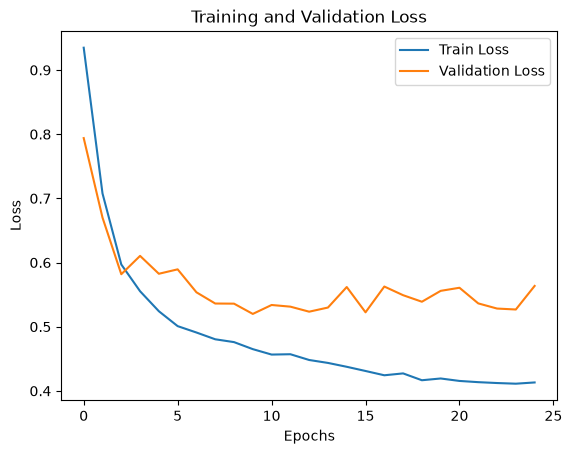

In [24]:
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

In [25]:
trained_model.eval()  
testA_loader = torch.utils.data.DataLoader(testA_dataset, batch_size=32, shuffle=False)
metrics, preds, targets = evaluate.evaluate_vision_model(trained_model, testA_loader, target_mean = train_dataset.target_mean, target_std = train_dataset.target_std)

In [26]:
print(metrics)

{'ankle': {'mae': np.float32(1.1089014), 'mse': np.float32(2.1364033), 'rmse': np.float32(1.461644), 'r2': np.float32(0.38794047)}, 'arm-length': {'mae': np.float32(2.1467752), 'mse': np.float32(7.470554), 'rmse': np.float32(2.7332313), 'r2': np.float32(0.29040694)}, 'bicep': {'mae': np.float32(2.3153622), 'mse': np.float32(8.812246), 'rmse': np.float32(2.9685428), 'r2': np.float32(0.4663666)}, 'calf': {'mae': np.float32(2.1714213), 'mse': np.float32(8.135039), 'rmse': np.float32(2.852199), 'r2': np.float32(0.23229545)}, 'chest': {'mae': np.float32(5.9932437), 'mse': np.float32(57.34133), 'rmse': np.float32(7.572406), 'r2': np.float32(0.5605128)}, 'forearm': {'mae': np.float32(1.5467101), 'mse': np.float32(3.7306767), 'rmse': np.float32(1.9314959), 'r2': np.float32(0.4945981)}, 'height': {'mae': np.float32(6.069994), 'mse': np.float32(58.834717), 'rmse': np.float32(7.670379), 'r2': np.float32(0.35875767)}, 'hip': {'mae': np.float32(5.0886264), 'mse': np.float32(45.0253), 'rmse': np.flo

Text(0, 0.5, 'Predictions')

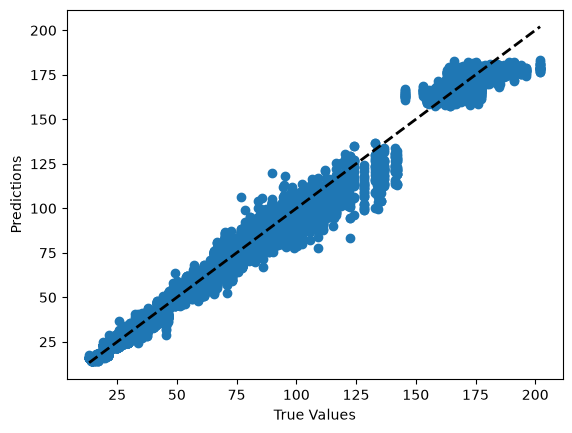

In [27]:
plt.scatter(targets, preds)
plt.plot([targets.min(), targets.max()], [targets.min(), targets.max()], 'k--', lw=2)
plt.xlabel('True Values')
plt.ylabel('Predictions')

In [28]:
"""
for i in range(14):
    plt.figure()
    plt.scatter(targets[:, i], preds[:, i])
    plt.plot([targets[:, i].min(), targets[:, i].max()], [targets[:, i].min(), targets[:, i].max()], 'k--', lw=2)
    plt.xlabel('True Values')
    plt.ylabel('Predictions')
    plt.title(f'Target {i+1}')
    plt.show()
"""

"\nfor i in range(14):\n    plt.figure()\n    plt.scatter(targets[:, i], preds[:, i])\n    plt.plot([targets[:, i].min(), targets[:, i].max()], [targets[:, i].min(), targets[:, i].max()], 'k--', lw=2)\n    plt.xlabel('True Values')\n    plt.ylabel('Predictions')\n    plt.title(f'Target {i+1}')\n    plt.show()\n"

Partial Unfreezing (didn't help with overfitting so keeping only phase 1 for now)

In [30]:
for param in trained_model.model.features[-2:].parameters():
    param.requires_grad = True

filtered_params = [p for p in trained_model.parameters() if p.requires_grad]

trained_model, history = train.train_vision_model(trained_model, train_dataset, testA_dataset, epochs = 100, lr=1e-5, weight_decay=1e-5)

Epoch   1 | train_loss: 0.4041 | val_loss: 0.5302 | val_mae: 0.5655
Epoch   2 | train_loss: 0.4036 | val_loss: 0.5473 | val_mae: 0.5741
Epoch   3 | train_loss: 0.4017 | val_loss: 0.5431 | val_mae: 0.5705
Epoch   4 | train_loss: 0.3962 | val_loss: 0.5332 | val_mae: 0.5663
Epoch   5 | train_loss: 0.3987 | val_loss: 0.5427 | val_mae: 0.5717
Epoch   6 | train_loss: 0.3936 | val_loss: 0.5380 | val_mae: 0.5691
Epoch   7 | train_loss: 0.3892 | val_loss: 0.5241 | val_mae: 0.5613
Epoch   8 | train_loss: 0.3808 | val_loss: 0.5316 | val_mae: 0.5654
Epoch   9 | train_loss: 0.3813 | val_loss: 0.5412 | val_mae: 0.5710
Epoch  10 | train_loss: 0.3808 | val_loss: 0.5590 | val_mae: 0.5808
Epoch  11 | train_loss: 0.3748 | val_loss: 0.5465 | val_mae: 0.5740
Epoch  12 | train_loss: 0.3793 | val_loss: 0.5295 | val_mae: 0.5650
Epoch  13 | train_loss: 0.3732 | val_loss: 0.5386 | val_mae: 0.5703
Epoch  14 | train_loss: 0.3703 | val_loss: 0.5307 | val_mae: 0.5653
Epoch  15 | train_loss: 0.3711 | val_loss: 0.543

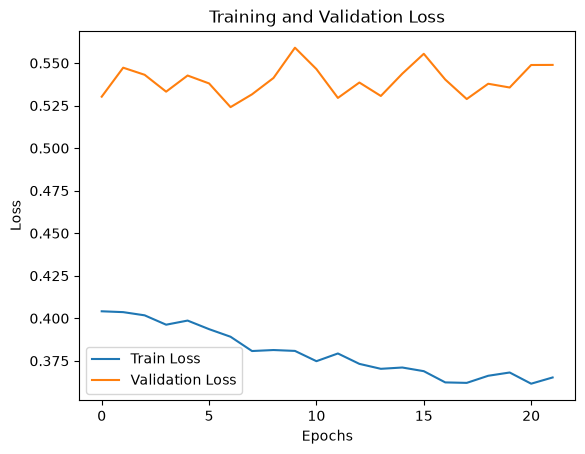

In [31]:
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

In [32]:
trained_model.eval()  
testA_loader = torch.utils.data.DataLoader(testA_dataset, batch_size=32, shuffle=False)
metrics, preds, targets = evaluate.evaluate_vision_model(trained_model, testA_loader, target_mean = train_dataset.target_mean, target_std = train_dataset.target_std)
print(metrics)

{'ankle': {'mae': np.float32(1.1026238), 'mse': np.float32(2.0928354), 'rmse': np.float32(1.4466635), 'r2': np.float32(0.40042222)}, 'arm-length': {'mae': np.float32(2.1141956), 'mse': np.float32(7.1776586), 'rmse': np.float32(2.6791153), 'r2': np.float32(0.3182277)}, 'bicep': {'mae': np.float32(2.2746964), 'mse': np.float32(8.712987), 'rmse': np.float32(2.951777), 'r2': np.float32(0.47237736)}, 'calf': {'mae': np.float32(2.121684), 'mse': np.float32(7.8502445), 'rmse': np.float32(2.8018289), 'r2': np.float32(0.25917155)}, 'chest': {'mae': np.float32(5.8632307), 'mse': np.float32(55.6745), 'rmse': np.float32(7.4615345), 'r2': np.float32(0.5732881)}, 'forearm': {'mae': np.float32(1.530932), 'mse': np.float32(3.69995), 'rmse': np.float32(1.9235255), 'r2': np.float32(0.49876064)}, 'height': {'mae': np.float32(5.9692416), 'mse': np.float32(56.854237), 'rmse': np.float32(7.540175), 'r2': np.float32(0.38034302)}, 'hip': {'mae': np.float32(5.011779), 'mse': np.float32(44.05427), 'rmse': np.fl

In [29]:
torch.save({
    "model_state_dict": trained_model.state_dict(),
    "in_channels": 2,
    "dropout_rate": 0.2,
    "output_size": 14,
    "target_mean": train_dataset.target_mean,
    "target_std": train_dataset.target_std,
    "measurement_cols": train_dataset.measurement_cols,
}, "../checkpoints/bodym_efficientnet.pt")